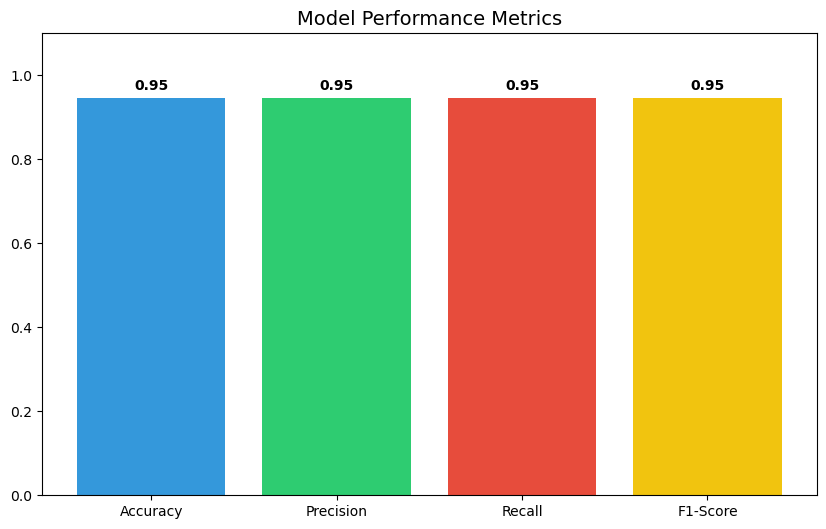

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.regularizers import l2
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. קיבוע מקריות ליציבות תוצאות בכל הרצה
tf.random.set_seed(42)
np.random.seed(42)

# הגדרות
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
file_path = r"C:\Users\USER\Desktop\לימודים\פרויקט גמר ב\סיוג חשבונות באינסטגרם - מאמר מחקר 2 אור\__דטאסט של מאמר 2 -עיבוד תכונות.xlsx"

# טעינה והכנה
df = pd.read_excel(file_path)
numeric_cols = ['Followers', 'Following', 'Following/Followers', 'Posts', 'Mutual Friends', 'Posts/(Following/Followers)']
feature_order = ['Followers', 'Following', 'Following/Followers', 'Posts', 'Mutual Friends', 'Posts/(Following/Followers)', 'Bio', 'Profile Picture', 'External Link', 'Threads']

X = df[feature_order]
y = df['Labels']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(64, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.4),
    Dense(32, activation='relu', kernel_regularizer=l2(0.01)),
    Dense(4, activation='softmax')
])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train_scaled, y_train, epochs=25, batch_size=32, verbose=0)

# 3. הצגת גרף מדדי ביצועים
y_pred = model.predict(X_test_scaled, verbose=0).argmax(axis=1)
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [
    accuracy_score(y_test, y_pred),
    precision_score(y_test, y_pred, average='weighted', zero_division=0),
    recall_score(y_test, y_pred, average='weighted', zero_division=0),
    f1_score(y_test, y_pred, average='weighted', zero_division=0)
]

plt.figure(figsize=(10, 6))
bars = plt.bar(metrics, values, color=['#3498db', '#2ecc71', '#e74c3c', '#f1c40f'])
plt.ylim(0, 1.1)
plt.title('Model Performance Metrics', fontsize=14)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, round(yval, 2), ha='center', fontweight='bold')
plt.show()



In [ ]:
# 4. פונקציית חיזוי אינטראקטיבית
def get_yes_no(prompt):
    while True:
        val = input(f"{prompt} (yes/no): ").lower().strip()
        if val == 'yes': return 1.0
        if val == 'no': return 0.0
        print("נא להקליד yes או no.")

def predict_interactive():
    print("\n--- הזיני נתונים עבור פרופיל חדש ---")
    data = {}
    for field in ['Followers', 'Following', 'Posts', 'Mutual Friends']:
        data[field] = float(input(f"הזיני ערך עבור {field}: "))
    for field in ['Bio', 'Profile Picture', 'External Link', 'Threads']:
        data[field] = get_yes_no(f"האם יש {field}?")
    
    data['Following/Followers'] = data['Following'] / data['Followers'] if data['Followers'] > 0 else 0
    data['Posts/(Following/Followers)'] = data['Posts'] / data['Following/Followers'] if data['Following/Followers'] > 0 else 0
    
    df_input = pd.DataFrame([data])[feature_order]
    df_input[numeric_cols] = scaler.transform(df_input[numeric_cols])
    
    probs = model.predict(df_input, verbose=0)
    res = ["Real", "Spam", "Bot", "Scam"][probs.argmax(axis=1)[0]]
    print(f"\n>>> סיווג: {res} (ביטחון: {np.max(probs)*100:.2f}%)")

predict_interactive()


--- הזיני נתונים עבור פרופיל חדש ---
